# ***MITIGATING POPULARITY BIAS IN RECOMMENATION SYSTEMS USING TEMPORAL SEQUENTIAL MODELLING***

**INSTALL ALL DEPENDENCIES**

In [ ]:
!pip uninstall gradio gradio-client -y
!pip install numpy==1.26.4
!pip install scikit-surprise --no-cache-dir
!pip install gradio==3.50.2
!pip install huggingface_hub==0.20.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 73.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554982 sha256=e8166741f0641d197a767bd658bf7962ce47e1075e273f96b8eb15d43b2bb76c
  Stored in directory: /tmp/pip-ephem-wheel-cache-p0ek6zhg/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.2/299.2 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 15.3 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.1/330.1 kB 25.1 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_

**VERIFY ALL INSTALLATIONS**

In [ ]:
import numpy as np
print("Numpy version:", np.__version__)      # should be 1.26.4

from surprise import Dataset, Reader, SVD
print("Surprise imported successfully!")

import gradio as gr
print("Gradio version:", gr.__version__)     # should be 3.50.2

Numpy version: 1.26.4
Surprise imported successfully!
Gradio version: 3.50.2


**MOUNT GOOGLE DRIVE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**IMPORT ALL LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
import tensorflow as tf
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy as surprise_accuracy

print("All libraries imported successfully!")


All libraries imported successfully!


**LOAD DATASET**

In [ ]:
file_path = "/content/drive/MyDrive/Reviews.csv"
df = pd.read_csv(file_path)
print("Raw dataset shape:", df.shape)

Raw dataset shape: (568454, 10)


**SELECT IMPORTANT COLUMNS**

In [ ]:
cols = ['UserId', 'ProductId', 'Score', 'Time']
df = df[cols]
print(df.head())


           UserId   ProductId  Score        Time
0  A3SGXH7AUHU8GW  B001E4KFG0      5  1303862400
1  A1D87F6ZCVE5NK  B00813GRG4      1  1346976000
2   ABXLMWJIXXAIN  B000LQOCH0      4  1219017600
3  A395BORC6FGVXV  B000UA0QIQ      2  1307923200
4  A1UQRSCLF8GW1T  B006K2ZZ7K      5  1350777600


**DATA CLEANING**

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print("After cleaning:", df.shape)


After cleaning: (565125, 4)


**TIME CONVERSION AND SORTING**

In [ ]:
df['Time'] = pd.to_datetime(df['Time'], unit='s')
df.sort_values(by=['UserId', 'Time'], inplace=True)
print(df.head())

                    UserId   ProductId  Score       Time
136322  #oc-R103C0QSV1DF5E  B006Q820X0      5 2012-07-24
516061  #oc-R109MU5OBBZ59U  B008I1XPKA      5 2012-10-13
516078  #oc-R10LFEMQEW6QGZ  B008I1XPKA      5 2012-08-26
378692  #oc-R10LT57ZGIB140  B0026LJ3EA      3 2011-07-14
136544  #oc-R10UA029WVWIUI  B006Q820X0      1 2012-07-17


**BEFORE FILTERING STATS**

In [ ]:
print("Before filtering:")
print("Users:", df['UserId'].nunique())
print("Interactions:", len(df))

df_before = df.copy()


Before filtering:
Users: 256059
Interactions: 565125


**APPLY INTERACTION FILTER (>= 5)**

In [ ]:
user_counts = df_before['UserId'].value_counts()
df = df_before[df_before['UserId'].isin(
    user_counts[user_counts >= 5].index
)].copy()

print("\nAfter filtering (>= 5 interactions):")
print("Users:", df['UserId'].nunique())
print("Interactions:", len(df))




After filtering (>= 5 interactions):
Users: 23515
Interactions: 240400


**VISUALIZATION: FILTERING IMPACT**

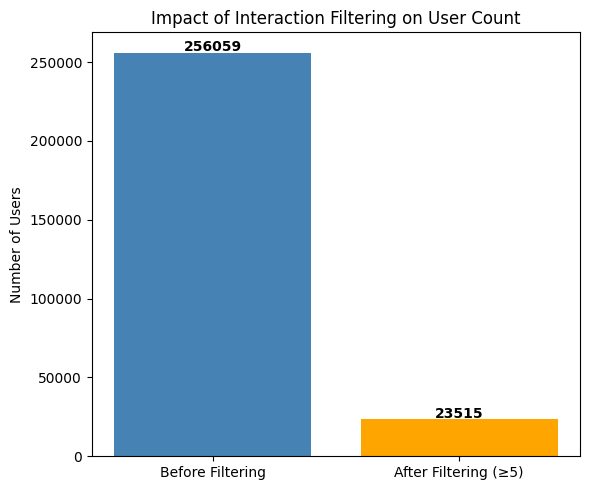

In [ ]:
users_before = df_before['UserId'].nunique()
users_after  = df['UserId'].nunique()

plt.figure(figsize=(6, 5))
plt.bar(
    ['Before Filtering', 'After Filtering (≥5)'],
    [users_before, users_after],
    color=['steelblue', 'orange']
)
plt.ylabel("Number of Users")
plt.title("Impact of Interaction Filtering on User Count")
for i, v in enumerate([users_before, users_after]):
    plt.text(i, v + 1000, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**LABEL ENCODING**

In [ ]:
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df['user_enc'] = user_encoder.fit_transform(df['UserId'])
df['item_enc'] = item_encoder.fit_transform(df['ProductId'])

print(df.head())
print("\nUnique users:", df['user_enc'].nunique())
print("Unique items:", df['item_enc'].nunique())

                UserId   ProductId  Score       Time  user_enc  item_enc
51950   A1001WMV1CL0XH  B005DGI1PW      5 2012-08-19         0     33172
344200  A1001WMV1CL0XH  B005EXGE5I      5 2012-08-19         0     33308
412887  A1001WMV1CL0XH  B005DGI242      5 2012-08-19         0     33174
430112  A1001WMV1CL0XH  B005DGI2II      5 2012-08-19         0     33175
431888  A1001WMV1CL0XH  B005DGI1IY      5 2012-08-19         0     33171

Unique users: 23515
Unique items: 37236


**BUILD USER SEQUENCES**

In [ ]:
df.sort_values(by=['UserId', 'Time'], inplace=True)

user_sequences = defaultdict(list)
for _, row in df.iterrows():
    user_sequences[row['user_enc']].append(row['item_enc'])

print("Total users with sequences:", len(user_sequences))


Total users with sequences: 23515


**CREATE TRAINING DATA**

In [ ]:
max_len = 30

X = []
y = []

for seq in user_sequences.values():
    for i in range(1, len(seq)):
        input_seq = seq[:i]
        target    = seq[i]
        if len(input_seq) > max_len:
            input_seq = input_seq[-max_len:]
        X.append(input_seq)
        y.append(target)

print("Total training samples:", len(X))


Total training samples: 216885


**PAD SEQUENCES**

In [ ]:
X_padded = pad_sequences(X, maxlen=max_len, padding='pre')
y        = np.array(y)

print("X_padded shape:", X_padded.shape)
print("y shape:", y.shape)

X_padded shape: (216885, 30)
y shape: (216885,)


**BUILD GRU MODEL**

In [ ]:
num_items = df['item_enc'].nunique()
print("Number of unique items:", num_items)

model = Sequential([
    Embedding(input_dim=num_items + 1, output_dim=128, input_length=max_len),
    GRU(128),
    Dropout(0.2),
    Dense(num_items, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Number of unique items: 37236


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**TRAIN GRU MODEL**

In [ ]:
history = model.fit(
    X_padded, y,
    batch_size=256,
    epochs=10,
    validation_split=0.1
)


Epoch 1/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.0257 - loss: 8.1930 - val_accuracy: 0.1108 - val_loss: 6.9949
Epoch 2/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.3023 - loss: 5.8749 - val_accuracy: 0.4340 - val_loss: 5.4104
Epoch 3/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.4685 - loss: 4.6322 - val_accuracy: 0.4998 - val_loss: 4.9821
Epoch 4/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.5128 - loss: 3.9895 - val_accuracy: 0.5229 - val_loss: 4.8603
Epoch 5/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5389 - loss: 3.4941 - val_accuracy: 0.5332 - val_loss: 4.8451
Epoch 6/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.5669 - loss: 3.0610 - val_accuracy: 0.5395 - val_loss: 4.8707
Epoch 7/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.6098 - loss: 2.6621 - val_accuracy: 0.5414 - val_loss: 4.9311
Epoch 8/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.6568 - loss: 2.3022 - 

**PLOT TRAINING HISTORY**

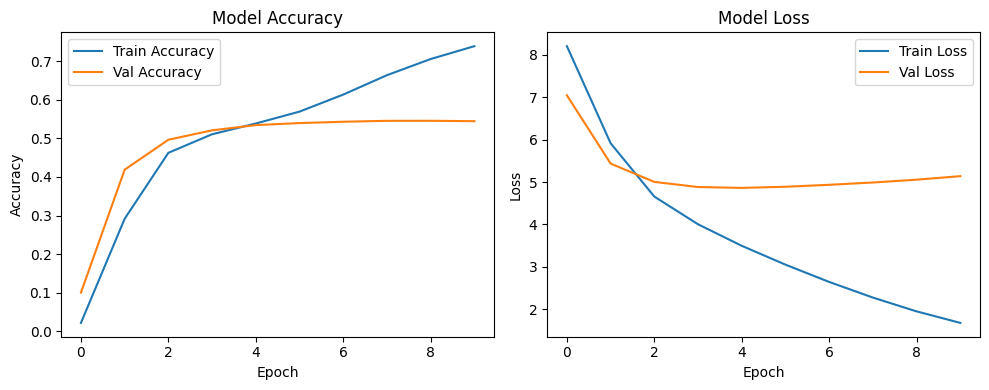

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


**DEFINE POPULAR ITEMS (Top 20%)**

In [ ]:
item_popularity = df['item_enc'].value_counts()
threshold       = int(0.2 * len(item_popularity))
popular_items   = set(item_popularity.head(threshold).index)

print(f"Total items:             {len(item_popularity)}")
print(f"Popular (top 20%):       {len(popular_items)}")
print(f"Long-tail (bottom 80%):  {len(item_popularity) - len(popular_items)}")


Total items:             37236
Popular (top 20%):       7447
Long-tail (bottom 80%):  29789


**GRU TOP-K PREDICTION FUNCTION**

In [ ]:
def get_top_k_gru(model, user_sequence, k=10):
    padded_seq  = pad_sequences([user_sequence], maxlen=max_len, padding='pre')
    preds       = model.predict(padded_seq, verbose=0)[0]
    top_k_items = np.argsort(preds)[-k:][::-1]
    return top_k_items

# Test on one user
sample_user    = list(user_sequences.keys())[0]
sample_input   = user_sequences[sample_user][-max_len:]
top_k_items    = get_top_k_gru(model, sample_input, k=10)
top_k_products = item_encoder.inverse_transform(top_k_items)

print("Top-K Product IDs:", top_k_products)

popular_count_gru_single = sum([1 for item in top_k_items if item in popular_items])
print(f"GRU Popular items in Top-K (single user): {popular_count_gru_single}/10")
print(f"GRU Popularity %: {popular_count_gru_single/10*100:.0f}%")



Top-K Product IDs: ['B003KSKU36' 'B005DGI1VG' 'B0047IGRCG' 'B004078WRW' 'B003YVRX5W'
 'B003NDF1MI' 'B004Z4LXLC' 'B0027EBPV0' 'B0002HDMCO' 'B007HP4OHQ']
GRU Popular items in Top-K (single user): 5/10
GRU Popularity %: 50%


**SVD BASELINE MODEL**

In [ ]:
data_df  = df[['UserId', 'ProductId', 'Score']]
reader   = Reader(rating_scale=(1, 5))
data     = Dataset.load_from_df(data_df, reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

svd = SVD(n_factors=50, random_state=42)
svd.fit(trainset)

predictions = svd.test(testset)
rmse        = surprise_accuracy.rmse(predictions)
print("SVD RMSE:", rmse)


RMSE: 0.8684
SVD RMSE: 0.86844133996141


**SVD TOP-K FUNCTION**

In [ ]:
def get_top_k_svd(svd, trainset, user_id, k=10):
    all_items     = trainset.all_items()
    all_items_raw = [trainset.to_raw_iid(i) for i in all_items]

    try:
        inner_uid = trainset.to_inner_uid(user_id)
    except ValueError:
        return []

    user_items     = set([j for (j, _) in trainset.ur[inner_uid]])
    user_items_raw = set([trainset.to_raw_iid(i) for i in user_items])
    candidates     = [item for item in all_items_raw if item not in user_items_raw]

    preds = [svd.predict(user_id, item) for item in candidates]
    preds.sort(key=lambda x: x.est, reverse=True)
    return [pred.iid for pred in preds[:k]]

# Test SVD on sample user
sample_user_id   = data_df['UserId'].iloc[0]
svd_top_k        = get_top_k_svd(svd, trainset, sample_user_id, k=10)
svd_top_k_encoded = item_encoder.transform(svd_top_k)

popular_count_svd = sum([1 for item in svd_top_k_encoded if item in popular_items])
svd_bias_value    = popular_count_svd / len(svd_top_k_encoded)

print(f"SVD Popular items in Top-K: {popular_count_svd}/10")
print(f"SVD Popularity Bias: {svd_bias_value*100:.0f}%")


SVD Popular items in Top-K: 10/10
SVD Popularity Bias: 100%


**MULTI-USER POPULARITY BIAS (GRU)**

In [ ]:
def average_popularity_bias_gru(model, user_sequences, popular_items, k=10, num_users=100):
    users            = list(user_sequences.keys())[:num_users]
    total_popularity = 0
    valid_users      = 0

    for user in users:
        seq = user_sequences[user]
        if len(seq) < 2:
            continue
        input_seq = seq[:-1]
        if len(input_seq) > max_len:
            input_seq = input_seq[-max_len:]

        padded_seq = pad_sequences([input_seq], maxlen=max_len, padding='pre')
        preds      = model.predict(padded_seq, verbose=0)[0]
        top_k      = np.argsort(preds)[-k:][::-1]

        popular_count     = sum([1 for item in top_k if item in popular_items])
        total_popularity += (popular_count / k)
        valid_users      += 1

    return total_popularity / valid_users


print("Computing GRU popularity bias over 100 users...")
gru_avg_bias = average_popularity_bias_gru(
    model, user_sequences, popular_items, k=10, num_users=100
)
print(f"GRU Average Popularity Bias: {gru_avg_bias*100:.0f}%")
print(f"GRU Long-tail Exposure:      {(1-gru_avg_bias)*100:.0f}%")

Computing GRU popularity bias over 100 users...
GRU Average Popularity Bias: 78%
GRU Long-tail Exposure:      22%


**POPULARITY BIAS COMPARISON CHARTS**

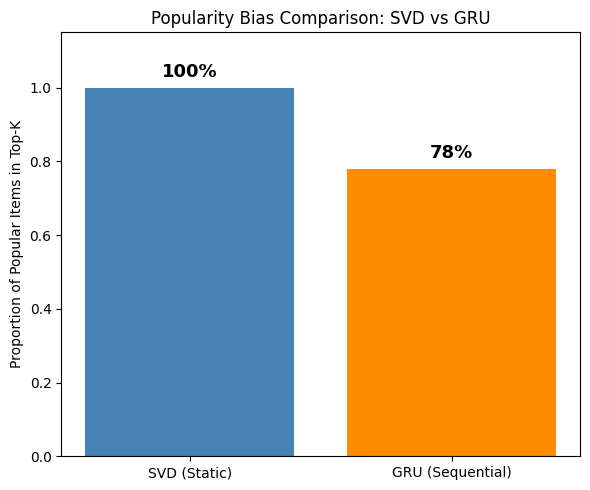

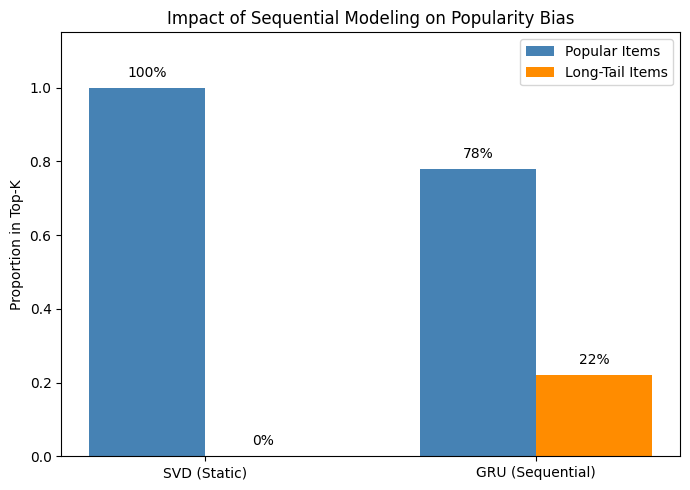

In [ ]:
models_label      = ['SVD (Static)', 'GRU (Sequential)']
popularity_values = [svd_bias_value, gru_avg_bias]
longtail_values   = [1 - svd_bias_value, 1 - gru_avg_bias]

# Chart 1 - Simple comparison
plt.figure(figsize=(6, 5))
plt.bar(models_label, popularity_values, color=['steelblue', 'darkorange'])
plt.ylabel("Proportion of Popular Items in Top-K")
plt.title("Popularity Bias Comparison: SVD vs GRU")
plt.ylim(0, 1.15)
for i, v in enumerate(popularity_values):
    plt.text(i, v + 0.03, f"{v*100:.0f}%", ha='center', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Chart 2 - Grouped bar chart
x     = np.arange(len(models_label))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, popularity_values, width, label='Popular Items',    color='steelblue')
plt.bar(x + width/2, longtail_values,   width, label='Long-Tail Items',  color='darkorange')
plt.xticks(x, models_label)
plt.ylabel("Proportion in Top-K")
plt.title("Impact of Sequential Modeling on Popularity Bias")
plt.ylim(0, 1.15)
plt.legend()
for i, v in enumerate(popularity_values):
    plt.text(i - width/2, v + 0.03, f"{v*100:.0f}%", ha='center', fontsize=10)
for i, v in enumerate(longtail_values):
    plt.text(i + width/2, v + 0.03, f"{v*100:.0f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**RECALL@K**

In [ ]:
def recall_at_k(model, user_sequences, k=10, num_users=1000):
    users = list(user_sequences.keys())[:num_users]
    hit   = 0
    total = 0

    for user in users:
        seq = user_sequences[user]
        if len(seq) < 2:
            continue
        input_seq = seq[:-1]
        target    = seq[-1]
        if len(input_seq) > max_len:
            input_seq = input_seq[-max_len:]

        padded_seq = pad_sequences([input_seq], maxlen=max_len, padding='pre')
        preds      = model.predict(padded_seq, verbose=0)[0]
        top_k      = np.argsort(preds)[-k:][::-1]

        if target in top_k:
            hit += 1
        total += 1

    return hit / total

print("Computing Recall@10 over 1000 users...")
print("(Please wait ~3 minutes...)")
recall = recall_at_k(model, user_sequences, k=10, num_users=1000)
print(f"Recall@10: {recall:.4f}")

Computing Recall@10 over 1000 users...
(Please wait ~3 minutes...)
Recall@10: 0.9270


**NDCG@K**

In [ ]:
def ndcg_at_k(model, user_sequences, k=10, num_users=1000):
    users       = list(user_sequences.keys())[:num_users]
    ndcg_total  = 0
    total       = 0

    for user in users:
        seq = user_sequences[user]
        if len(seq) < 2:
            continue
        input_seq = seq[:-1]
        target    = seq[-1]
        if len(input_seq) > max_len:
            input_seq = input_seq[-max_len:]

        padded_seq = pad_sequences([input_seq], maxlen=max_len, padding='pre')
        preds      = model.predict(padded_seq, verbose=0)[0]
        top_k      = list(np.argsort(preds)[-k:][::-1])

        if target in top_k:
            rank        = top_k.index(target) + 1
            ndcg_total += 1 / np.log2(rank + 1)
        total += 1

    return ndcg_total / total


recall = recall_at_k(model, user_sequences, k=10, num_users=1000)
print(f"Recall@10: {recall:.4f}")

ndcg = ndcg_at_k(model, user_sequences, k=10, num_users=1000)
print(f"NDCG@10: {ndcg:.4f}")


Recall@10: 0.9270
NDCG@10: 0.8760


**SAVE MODEL AND ENCODERS**

In [ ]:
model.save('/content/drive/MyDrive/gru_model.keras')

with open('/content/drive/MyDrive/user_encoder.pkl', 'wb') as f:
    pickle.dump(user_encoder, f)

with open('/content/drive/MyDrive/item_encoder.pkl', 'wb') as f:
    pickle.dump(item_encoder, f)

with open('/content/drive/MyDrive/user_sequences.pkl', 'wb') as f:
    pickle.dump(user_sequences, f)

print("All files saved to Google Drive successfully!")

All files saved to Google Drive successfully!


**DEMO WITHOUT GRADIO**

In [ ]:
def demo_recommendation(user_id):
    if user_id not in user_sequences:
        print(f"Invalid User ID. Try between 0 and {len(user_sequences)-1}")
        return

    original_user = user_encoder.inverse_transform([user_id])[0]
    user_seq      = user_sequences[user_id][-max_len:]
    padded_seq    = pad_sequences([user_seq], maxlen=max_len, padding='pre')

    preds  = model.predict(padded_seq, verbose=0)[0]
    top_k  = preds.argsort()[-10:][::-1]

    popular_in_recs = 0
    print(f"\n User ID: {user_id}  |  Original ID: {original_user}")
    print("-" * 50)
    for rank, item in enumerate(top_k, 1):
        product_id = item_encoder.inverse_transform([item])[0]
        tag = "Popular" if item in popular_items else "Long-tail"
        if item in popular_items:
            popular_in_recs += 1
        print(f"  {rank:2}. {product_id}  —  {tag}")
    print("-" * 50)
    print(f"  Popularity Bias:    {popular_in_recs/10*100:.0f}%")
    print(f"  Long-tail Exposure: {(10-popular_in_recs)/10*100:.0f}%")

# Test on multiple users
demo_recommendation(0)
demo_recommendation(5)
demo_recommendation(100)


 User ID: 0  |  Original ID: A1001WMV1CL0XH
--------------------------------------------------
   1. B003KSKU36  —  Long-tail
   2. B005DGI1VG  —  Popular
   3. B0047IGRCG  —  Popular
   4. B004078WRW  —  Long-tail
   5. B003YVRX5W  —  Long-tail
   6. B003NDF1MI  —  Popular
   7. B004Z4LXLC  —  Popular
   8. B0027EBPV0  —  Popular
   9. B0002HDMCO  —  Long-tail
  10. B007HP4OHQ  —  Long-tail
--------------------------------------------------
  Popularity Bias:    50%
  Long-tail Exposure: 50%

 User ID: 5  |  Original ID: A100WO06OQR8BQ
--------------------------------------------------
   1. B0014DUG9M  —  Long-tail
   2. B001E5E20O  —  Popular
   3. B003MWERTS  —  Long-tail
   4. B000MTM0WK  —  Popular
   5. B0013Z40U2  —  Popular
   6. B003L7DFQA  —  Popular
   7. B000JIN1H2  —  Popular
   8. B001GVIR9S  —  Popular
   9. B0013NUGDE  —  Popular
  10. B000LKTXQG  —  Popular
--------------------------------------------------
  Popularity Bias:    80%
  Long-tail Exposure: 20%

 User I

**GRADIO UI**

In [ ]:
import gradio as gr

def recommend_products(user_id_input):
    try:
        user_id = int(user_id_input)
        if user_id not in user_sequences:
            return f"Invalid User ID. Try between 0 and {len(user_sequences)-1}"

        original_user = user_encoder.inverse_transform([user_id])[0]
        user_seq      = user_sequences[user_id][-max_len:]
        padded_seq    = pad_sequences([user_seq], maxlen=max_len, padding='pre')

        preds  = model.predict(padded_seq, verbose=0)[0]
        top_k  = preds.argsort()[-10:][::-1]

        popular_in_recs = 0
        output  = f"User: {original_user}\n"
        output += "-" * 45 + "\n"

        for rank, item in enumerate(top_k, 1):
            product_id = item_encoder.inverse_transform([item])[0]
            tag = "Popular" if item in popular_items else "Long-tail"
            if item in popular_items:
                popular_in_recs += 1
            output += f"{rank:2}. {product_id}  —  {tag}\n"

        output += "-" * 45 + "\n"
        output += f"Popularity Bias:    {popular_in_recs/10*100:.0f}%\n"
        output += f"Long-tail Exposure: {(10-popular_in_recs)/10*100:.0f}%"
        return output

    except ValueError:
        return "Please enter a valid integer User ID."
    except Exception as e:
        return f"Error: {str(e)}"


app = gr.Interface(
    fn=recommend_products,
    inputs="text",
    outputs="text",
    title="E-Commerce Recommendation System",
    description="GRU-based Personalized Recommendations with Popularity Bias Analysis"
)

app.launch(share=True)


IMPORTANT: You are using gradio version 3.50.2, however version 4.44.1 is available, please upgrade.
--------
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://4d614f16ec8616ba84.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


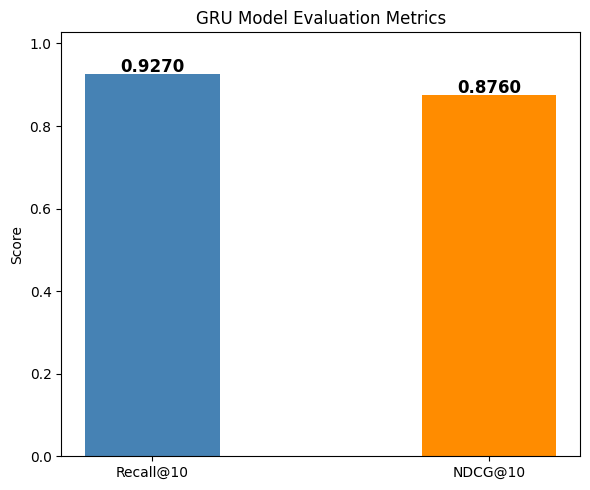

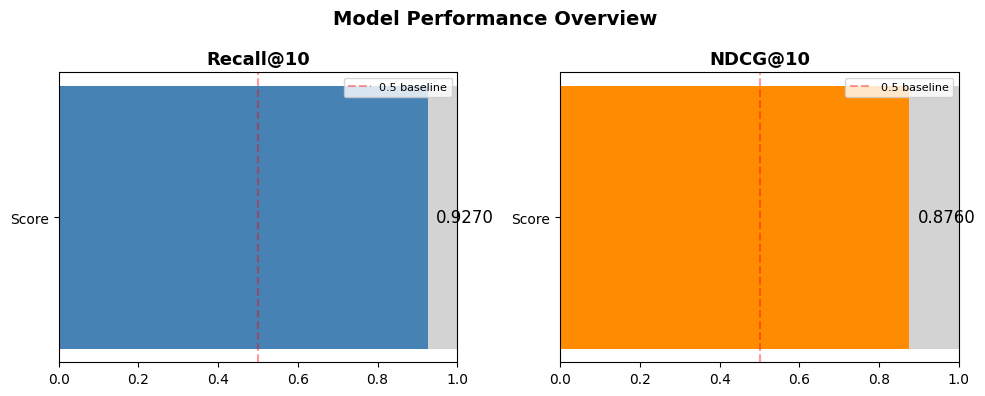

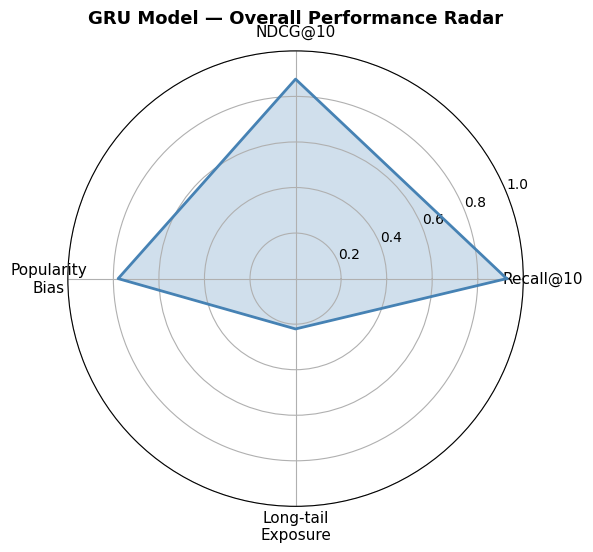

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your metric values
metrics = ['Recall@10', 'NDCG@10']
values  = [recall, ndcg]
colors  = ['steelblue', 'darkorange']

# Chart 1 - Bar chart
plt.figure(figsize=(6, 5))
bars = plt.bar(metrics, values, color=colors, width=0.4)
plt.ylim(0, max(values) + 0.1)
plt.title("GRU Model Evaluation Metrics")
plt.ylabel("Score")
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{val:.4f}", ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Chart 2 - Gauge-style comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric, value, color in zip(axes, metrics, values, colors):
    ax.barh(['Score'], [value], color=color, height=0.4)
    ax.barh(['Score'], [1],     color='lightgrey', height=0.4, zorder=0)
    ax.set_xlim(0, 1)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.text(value + 0.02, 0, f"{value:.4f}", va='center', fontsize=12)
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4, label='0.5 baseline')
    ax.legend(fontsize=8)
plt.suptitle("Model Performance Overview", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Chart 3 - Radar/Spider chart
categories = ['Recall@10', 'NDCG@10', 'Popularity\nBias', 'Long-tail\nExposure']
values_radar = [recall, ndcg, gru_avg_bias, 1 - gru_avg_bias]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values_radar += values_radar[:1]  # close the loop
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values_radar, color='steelblue', linewidth=2)
ax.fill(angles, values_radar, color='steelblue', alpha=0.25)
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("GRU Model — Overall Performance Radar", fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
!pip install huggingface_hub

# Then login
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import login
from google.colab import userdata

token = userdata.get('HF_TOKEN')
login(token=token)

In [ ]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '69c1770750b38cba2ba4ccdd', 'name': 'hemu2109', 'fullname': 'Hema', 'email': 'hemupookie2109@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1775001600, 'isPro': False, 'avatarUrl': '/avatars/84c9d87c2fe1663c15eb4dee7729c817.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'gradio', 'role': 'write', 'createdAt': '2026-03-23T17:29:59.752Z'}}}


In [ ]:
from huggingface_hub import HfApi
import os

# Create the space
api = HfApi()
api.create_repo(
    repo_id="hemu2109/recommendation-system",
    repo_type="space",
    space_sdk="gradio",
    token=token,
    exist_ok=True
)

# Save your app code to a file
app_code = '''
import gradio as gr
import pickle
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load your model and encoders here
model = load_model("model.h5")
# add rest of your loading code...
'''

# Upload the file
with open("app.py", "w") as f:
    f.write(app_code)

api.upload_file(
    path_or_fileobj="app.py",
    path_in_repo="app.py",
    repo_id="hemu2109/recommendation-system",
    repo_type="space",
    token=token
)

print("✅ Deployed! Visit: https://huggingface.co/spaces/hemu2109/recommendation-system")

✅ Deployed! Visit: https://huggingface.co/spaces/hemu2109/recommendation-system


In [ ]:
# Create requirements.txt
requirements = """tensorflow
gradio
numpy
scikit-learn
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

# Upload it to your Space
api.upload_file(
    path_or_fileobj="requirements.txt",
    path_in_repo="requirements.txt",
    repo_id="hemu2109/recommendation-system",
    repo_type="space",
    token=token
)

print("✅ requirements.txt uploaded!")

✅ requirements.txt uploaded!
